In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the raw consumption data
consumption_path = '../../../data/paraguay/electricity-consumption-raw.csv'
df_consumption = pd.read_csv(consumption_path)

# Identify feeder columns (assuming time columns are first, feeders are the rest)
time_cols = [col for col in df_consumption.columns if 'time' in col.lower() or 'date' in col.lower()]
feeder_cols = [col for col in df_consumption.columns if col not in time_cols]

# If the feeder column is named 'feeder', get all unique feeders
if 'feeder' in df_consumption.columns:
    unique_feeders = df_consumption['feeder'].unique()

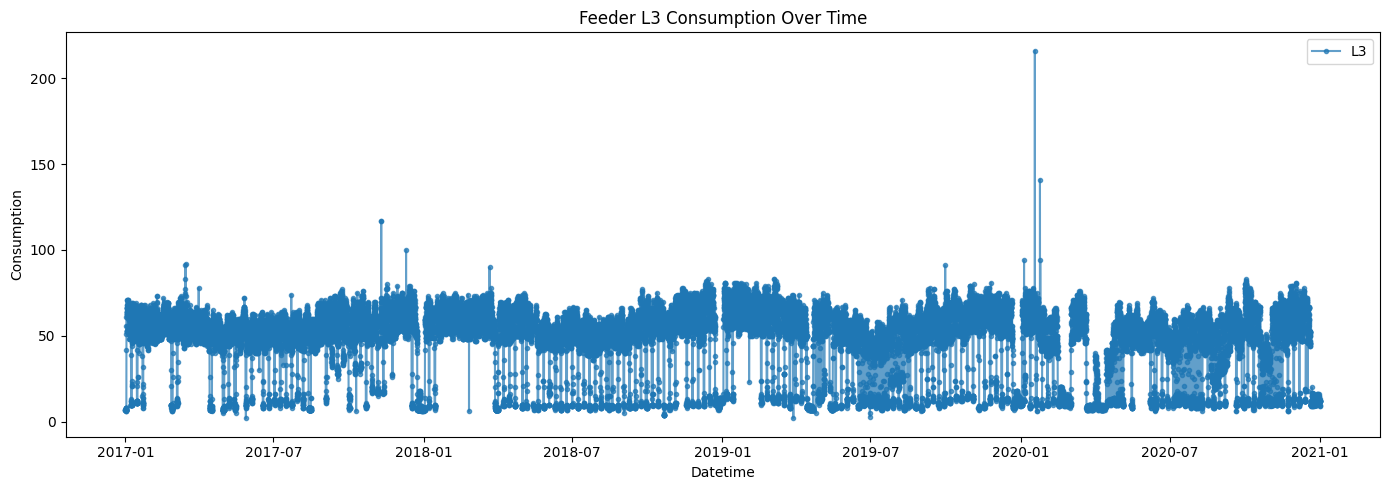

In [3]:
feeder = 'L3'

plt.figure(figsize=(14, 5))
df_f = df_consumption[df_consumption['feeder'] == feeder].copy()
df_f['datetime'] = pd.to_datetime(df_f['datetime'])
plt.plot(df_f['datetime'], df_f['consumption'], marker='.', linestyle='-', alpha=0.7, label=f'{feeder}')
plt.xlabel('Datetime')
plt.ylabel('Consumption')
plt.title(f'Feeder {feeder} Consumption Over Time')
plt.legend()
plt.tight_layout()
plt.show()

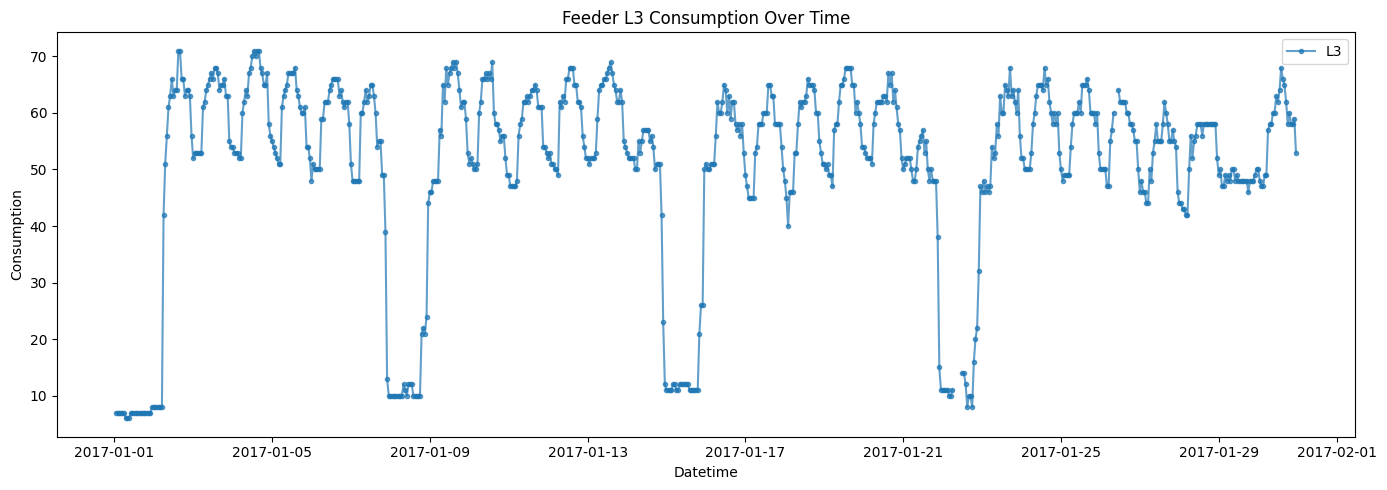

In [4]:
#Plot first month of consumption data for feeder L3

plt.figure(figsize=(14, 5))
df_f = df_consumption[df_consumption['feeder'] == feeder].copy()[:720]  # First month assuming half-hourly data
df_f['datetime'] = pd.to_datetime(df_f['datetime'])
plt.plot(df_f['datetime'], df_f['consumption'], marker='.', linestyle='-', alpha=0.7, label=feeder)
plt.xlabel('Datetime')
plt.ylabel('Consumption')
plt.title(f'Feeder {feeder} Consumption Over Time')
plt.legend()
plt.tight_layout()

# Exploring Outlier Detection Methods

In this section, we will compare several outlier detection methods for time series data:
- IQR (Interquartile Range, current method)
- Z-score

We will visualize and compare their effectiveness for weekly outlier detection and discuss the best approach for removing outliers.

In [5]:
def rolling_zscore_outliers(df, window_hours, threshold=3):
    """
    Detect outliers using rolling Z-score method.
    
    This function calculates Z-scores using a rolling window approach, where the mean 
    and standard deviation are computed over a sliding window centered at each point.
    Points with absolute Z-scores exceeding the threshold are flagged as outliers.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing time series data with a 'consumption' column
    window_hours : int
        Size of the rolling window in hours. This determines how many data points
        (assuming hourly data) are used to calculate the local mean and std deviation.
        Common values:
        - 24*7 = 168 (1 week)
        - 24*30 = 720 (1 month) 
        - 24*90 = 2160 (3 months)
    threshold : float, default=3
        Z-score threshold for outlier detection. Points with |z-score| > threshold
        are considered outliers. Common values:
        - 2.0: ~95% of normal data retained (more sensitive)
        - 2.7: ~99% of normal data retained (balanced)
        - 3.0: ~99.7% of normal data retained (less sensitive)
        
    Returns:
    --------
    pandas.Series
        Boolean series where True indicates an outlier, False indicates normal data
        
    Notes:
    ------
    - Uses center=True for symmetric windows around each point
    - Adds small constant (1e-9) to std to avoid division by zero
    - min_periods=1 ensures calculations even at edges with partial windows
    - Higher thresholds = fewer outliers detected (more conservative)
    - Lower thresholds = more outliers detected (more aggressive)
    """
    df = df.copy()
    
    # Calculate rolling mean and standard deviation
    roll_mean = df['consumption'].rolling(window_hours, center=True, min_periods=1).mean()
    roll_std = df['consumption'].rolling(window_hours, center=True, min_periods=1).std()
    
    # Calculate Z-score: (value - local_mean) / local_std
    # Add small constant to std to prevent division by zero
    z = (df['consumption'] - roll_mean) / (roll_std + 1e-9)
    
    # Return boolean mask where absolute Z-score exceeds threshold
    return np.abs(z) > threshold


In [6]:
def rolling_iqr_outliers(df, window_hours):
    df = df.copy()
    roll_Q1 = df['consumption'].rolling(window_hours, center=True, min_periods=1).quantile(0.25)
    roll_Q3 = df['consumption'].rolling(window_hours, center=True, min_periods=1).quantile(0.75)
    roll_IQR = roll_Q3 - roll_Q1
    lower = roll_Q1 - 1.5 * roll_IQR
    upper = roll_Q3 + 1.5 * roll_IQR
    return (df['consumption'] < lower) | (df['consumption'] > upper)

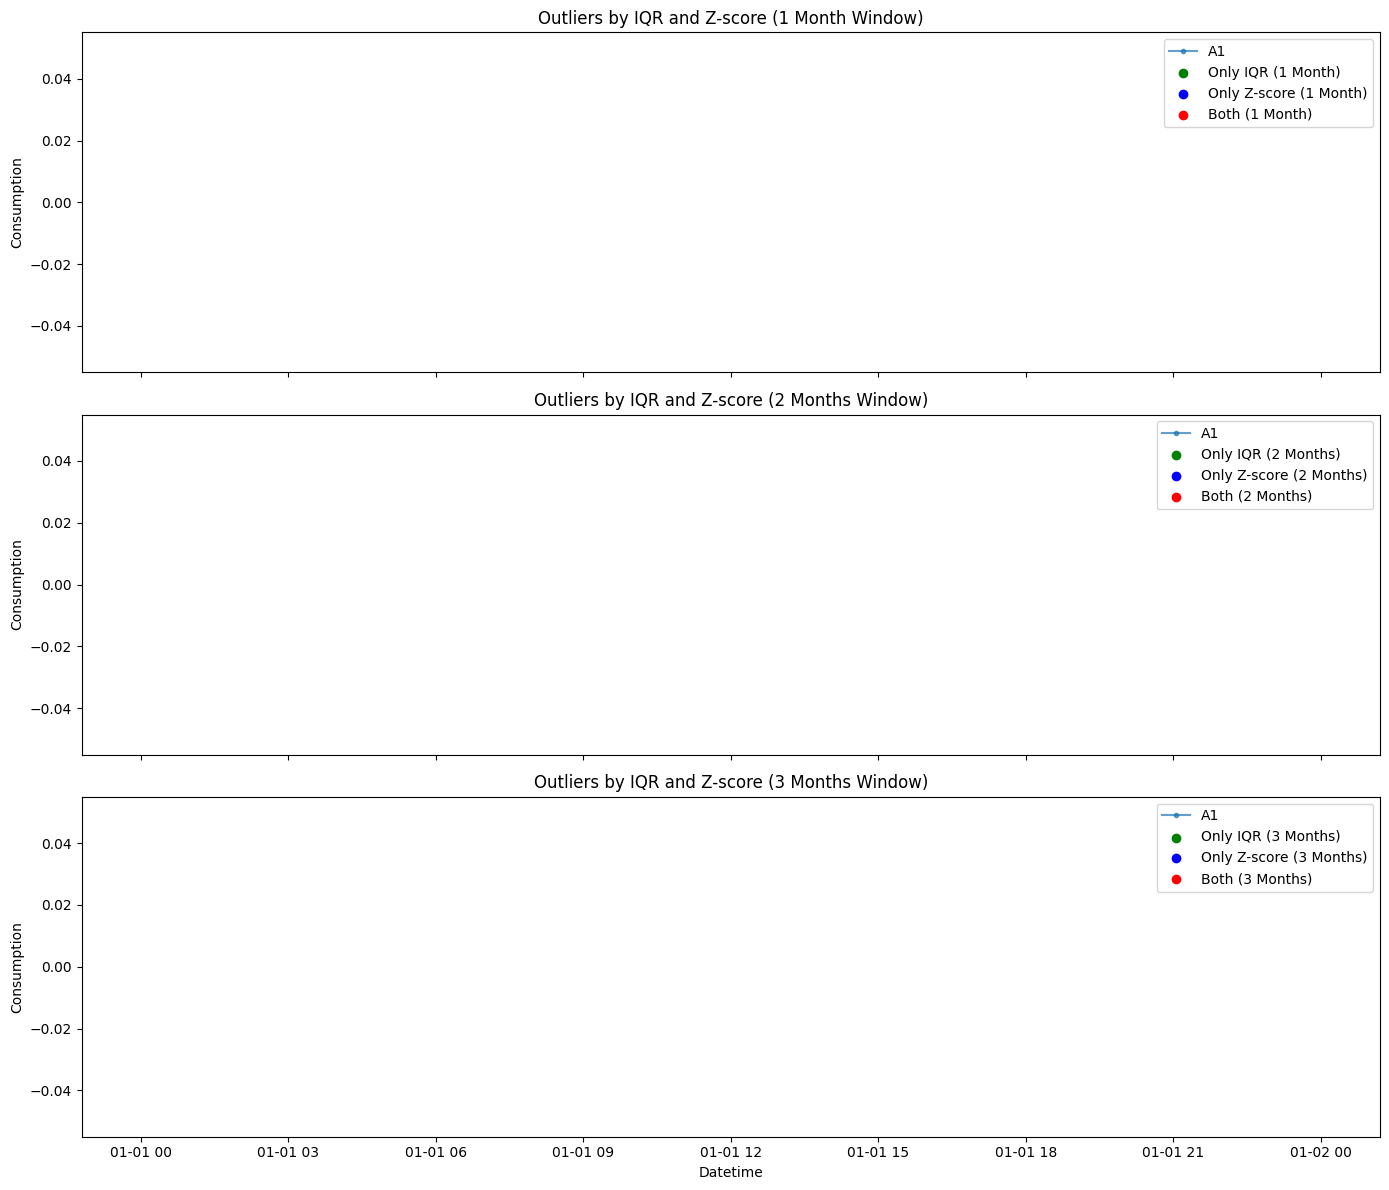

In [7]:
# Z-score outlier detection for rolling windows from 1 to 7 days, 1-4 weeks, and 1-3 months
windows_days = list(range(0))
windows_weeks = [] #[7, 14, 21, 28]  # 1, 2, 3, 4 weeks in days
windows_months = [30, 60, 90]  # Approximate months as 30 days each
all_windows = windows_days + windows_weeks + windows_months
labels = (
    [f'{d} Day' if d == 1 else f'{d} Days' for d in windows_days] +
    [f'{w//7} Week' if w == 7 else f'{w//7} Weeks' for w in windows_weeks] +
    [f'{m//30} Month' if m == 30 else f'{m//30} Months' for m in windows_months]
)

start_day = "01-01-2018"
end_day = "01-03-2020"

fig, axs = plt.subplots(len(all_windows), 1, figsize=(14, 4*len(all_windows)), sharex=True)
for i, (win, label) in enumerate(zip(all_windows, labels)):
    win_hours = win * 24
    # Calculate outlier masks for this window
    iqr_mask = rolling_iqr_outliers(df_f, win_hours)
    zscore_mask = rolling_zscore_outliers(df_f, win_hours, threshold=2.7)
    both_mask = iqr_mask & zscore_mask
    only_iqr_mask = iqr_mask & ~zscore_mask
    only_zscore_mask = zscore_mask & ~iqr_mask

    #plot only data from start_day to end_day
    mask = (df_f['datetime'] >= start_day) & (df_f['datetime'] <= end_day)
    df_f = df_f.loc[mask]
    axs[i].plot(df_f['datetime'], df_f['consumption'], marker='.', linestyle='-', alpha=0.7, label='A1')

    # Scatter: green = only IQR, blue = only Z-score, red = both
    axs[i].scatter(df_f.loc[only_iqr_mask, 'datetime'], df_f.loc[only_iqr_mask, 'consumption'], color='green', label=f'Only IQR ({label})', zorder=5)
    axs[i].scatter(df_f.loc[only_zscore_mask, 'datetime'], df_f.loc[only_zscore_mask, 'consumption'], color='blue', label=f'Only Z-score ({label})', zorder=5)
    axs[i].scatter(df_f.loc[both_mask, 'datetime'], df_f.loc[both_mask, 'consumption'], color='red', label=f'Both ({label})', zorder=5)

    axs[i].set_title(f'Outliers by IQR and Z-score ({label} Window)')
    axs[i].set_ylabel('Consumption')
    axs[i].legend()
axs[-1].set_xlabel('Datetime')
plt.tight_layout()
plt.show()

# Testing Z-score Method for Outlier Detection

test z-score on all or some feeders with a rolling window 

In [8]:
# Plot all feeders with outliers (Z-score, 1 month window)
# unique_feeders = df_consumption['feeder'].unique()
# window_hours = 30 * 24  # 1 month
# num_feeders = 55 #len(unique_feeders)
# fig, axs = plt.subplots(num_feeders, 1, figsize=(14, 4*num_feeders), sharex=True)
# if num_feeders == 1:
#     axs = [axs]
# for i, feeder in enumerate(unique_feeders[:num_feeders]):
#     df_f = df_consumption[df_consumption['feeder'] == feeder].copy()
#     df_f['datetime'] = pd.to_datetime(df_f['datetime'])
#     zscore_mask = rolling_zscore_outliers(df_f, window_hours, threshold=4)
#     axs[i].plot(df_f['datetime'], df_f['consumption'], marker='.', linestyle='-', alpha=0.7, label=f'{feeder}')
#     axs[i].scatter(df_f.loc[zscore_mask, 'datetime'], df_f.loc[zscore_mask, 'consumption'], color='red', label='Z-score Outliers (1 Month)', zorder=5)
#     axs[i].set_title(f'Feeder {feeder} with Z-score Outliers (1 Month Window)')
#     axs[i].set_ylabel('Consumption')
#     axs[i].legend()
# axs[-1].set_xlabel('Datetime')
# plt.tight_layout()
# plt.show()

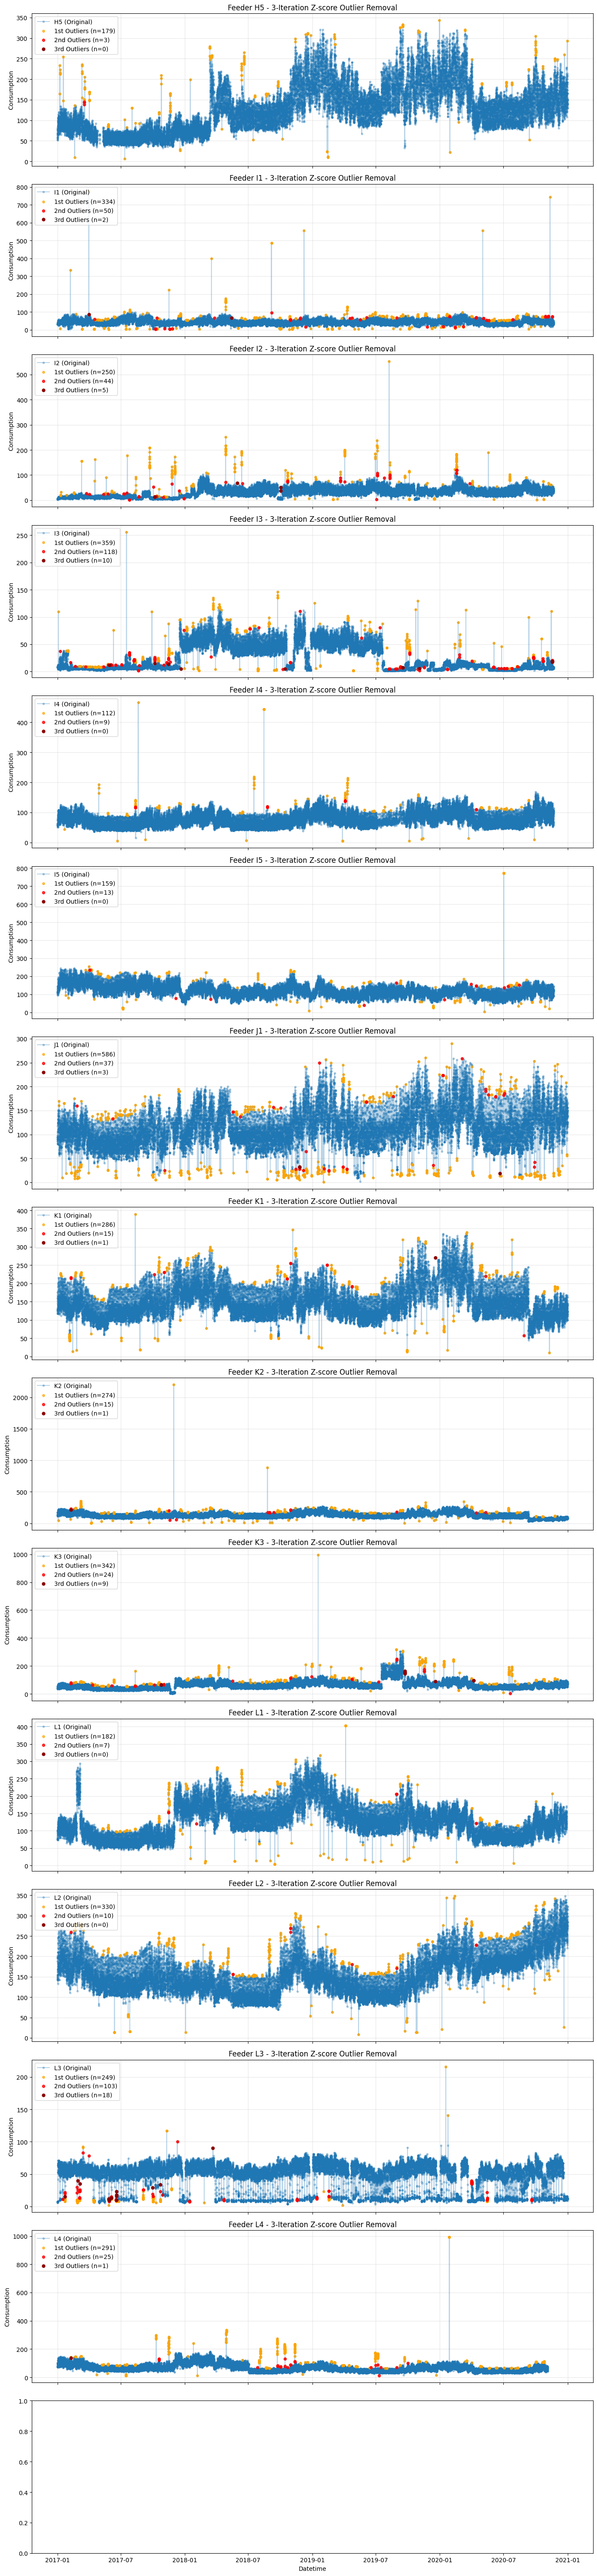

In [18]:
# Plot feeders with iterative Z-score outlier removal (1 month window)
num_feeders = 15
fig, axs = plt.subplots(num_feeders, 1, figsize=(14, 4*num_feeders), sharex=True)
if num_feeders == 1:
    axs = [axs]

window_hours = 30 * 24
for i, feeder in enumerate(unique_feeders[30:44]):
    df_f = df_consumption[df_consumption['feeder'] == feeder].copy()
    df_f['datetime'] = pd.to_datetime(df_f['datetime'])
    
    # First iteration: Calculate rolling Z-score outliers
    zscore_mask_1 = rolling_zscore_outliers(df_f, window_hours, threshold=2.60)
    
    # Calculate rolling 75th percentile for capping first iteration
    percentile_75_1 = df_f['consumption'].rolling(window_hours, center=True, min_periods=1).quantile(0.75)
    
    # Create first capped consumption column
    df_f['consumption_capped_1'] = df_f['consumption'].copy()
    df_f.loc[zscore_mask_1, 'consumption_capped_1'] = percentile_75_1[zscore_mask_1]
    
    # Second iteration: Apply Z-score on already capped data
    window_hours_2 = 14 * 24
    df_temp = df_f.copy()
    df_temp['consumption'] = df_f['consumption_capped_1']
    zscore_mask_2 = rolling_zscore_outliers(df_temp, window_hours_2, threshold=3)

    # Calculate rolling 75th percentile for second capping
    percentile_75_2 = df_f['consumption_capped_1'].rolling(window_hours_2, center=True, min_periods=1).quantile(0.75)
    
    # Create second capped consumption column
    df_f['consumption_capped_2'] = df_f['consumption_capped_1'].copy()
    df_f.loc[zscore_mask_2, 'consumption_capped_2'] = percentile_75_2[zscore_mask_2]
    
    # Third iteration: Apply Z-score on second capped data
    window_hours_3 = 7 * 24
    df_temp2 = df_f.copy()
    df_temp2['consumption'] = df_f['consumption_capped_2']
    zscore_mask_3 = rolling_zscore_outliers(df_temp2, window_hours_3, threshold=3.5)
    
    # Calculate rolling 75th percentile for third capping
    percentile_75_3 = df_f['consumption_capped_2'].rolling(window_hours_3, center=True, min_periods=1).quantile(0.75)
    
    # Create final capped consumption column
    df_f['consumption_capped_3'] = df_f['consumption_capped_2'].copy()
    df_f.loc[zscore_mask_3, 'consumption_capped_3'] = percentile_75_3[zscore_mask_3]
    
    # Plot original data
    axs[i].plot(df_f['datetime'], df_f['consumption'], marker='.', linestyle='-', alpha=0.3, label=f'{feeder} (Original)')
    
    # Plot first iteration capped data
    #axs[i].plot(df_f['datetime'], df_f['consumption_capped_1'], marker='.', linestyle='-', alpha=0.5, label=f'{feeder} (1st iteration)', color='lightblue')
    
    # Plot second iteration capped data
    #axs[i].plot(df_f['datetime'], df_f['consumption_capped_2'], marker='.', linestyle='-', alpha=0.7, label=f'{feeder} (2nd iteration)', color='blue')
    
    # Plot final capped data
    #axs[i].plot(df_f['datetime'], df_f['consumption_capped_3'], marker='.', linestyle='-', alpha=0.9, label=f'{feeder} (3rd iteration)')
    
    # Highlight first iteration outliers
    axs[i].scatter(df_f.loc[zscore_mask_1, 'datetime'], df_f.loc[zscore_mask_1, 'consumption'], 
                   color='orange', label=f'1st Outliers (n={zscore_mask_1.sum()})', zorder=4, s=15, alpha=0.7)
    
    # Highlight second iteration outliers
    axs[i].scatter(df_f.loc[zscore_mask_2, 'datetime'], df_f.loc[zscore_mask_2, 'consumption_capped_1'], 
                   color='red', label=f'2nd Outliers (n={zscore_mask_2.sum()})', zorder=5, s=20, alpha=0.8)
    
    # Highlight third iteration outliers
    axs[i].scatter(df_f.loc[zscore_mask_3, 'datetime'], df_f.loc[zscore_mask_3, 'consumption_capped_2'], 
                   color='darkred', label=f'3rd Outliers (n={zscore_mask_3.sum()})', zorder=6, s=25)
    
    axs[i].set_title(f'Feeder {feeder} - 3-Iteration Z-score Outlier Removal')
    axs[i].set_ylabel('Consumption')
    #force legend not to overlap with data
    axs[i].legend(loc='upper left')
    axs[i].grid(True, alpha=0.3)

axs[-1].set_xlabel('Datetime')
plt.tight_layout()
plt.show()


In [10]:
# --- Outlier Summary Statistics ---
total_points = 0
total_outliers = 0
outlier_percentages = {}
for feeder in unique_feeders:
    df_f = df_consumption[df_consumption['feeder'] == feeder].copy()
    df_f['datetime'] = pd.to_datetime(df_f['datetime'])
    zscore_mask = rolling_zscore_outliers(df_f, window_hours)
    n_points = len(df_f)
    n_outliers = zscore_mask.sum()
    total_points += n_points
    total_outliers += n_outliers
    percent = (n_outliers / n_points * 100) if n_points > 0 else 0
    outlier_percentages[feeder] = percent

if outlier_percentages:
    feeder_most = max(outlier_percentages, key=outlier_percentages.get)
    feeder_least = min(outlier_percentages, key=outlier_percentages.get)
    print(f"Total data points: {total_points}")
    print(f"Total outliers (Z-score, 1 month window): {total_outliers}")
    print(f"Overall outlier percentage: {total_outliers/total_points*100:.2f}%")
    print(f"Feeder with most outliers: {feeder_most} ({outlier_percentages[feeder_most]:.2f}%)")
    print(f"Feeder with least outliers: {feeder_least} ({outlier_percentages[feeder_least]:.2f}%)")
else:
    print("No feeders found for outlier summary.")

Total data points: 1899312
Total outliers (Z-score, 1 month window): 5458
Overall outlier percentage: 0.29%
Feeder with most outliers: M2 (0.82%)
Feeder with least outliers: L3 (0.05%)


C:\Users\knuto\AppData\Local\Temp\ipykernel_38508\3205826967.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df_f['consumption'].interpolate().fillna(method='bfill').fillna(method='ffill')


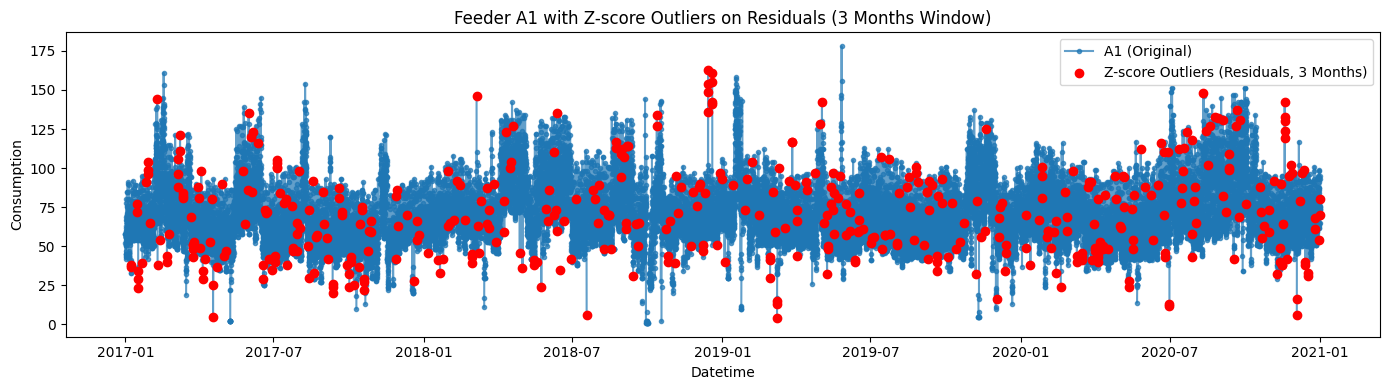

In [11]:
from statsmodels.tsa.seasonal import STL

# Decompose and apply Z-score to residuals for all feeders (3 month window)
window_hours = 3 * 24  # 3 months
num_feeders = 1 #len(unique_feeders)
fig, axs = plt.subplots(num_feeders, 1, figsize=(14, 4*num_feeders), sharex=True)
if num_feeders == 1:
    axs = [axs]
for i, feeder in enumerate(unique_feeders[:num_feeders]):
    df_f = df_consumption[df_consumption['feeder'] == feeder].copy()
    df_f['datetime'] = pd.to_datetime(df_f['datetime'])
    df_f = df_f.sort_values('datetime')
    # Fill missing values for decomposition
    y = df_f['consumption'].interpolate().fillna(method='bfill').fillna(method='ffill')
    stl = STL(y, period=24*7, robust=True)
    res = stl.fit()
    df_f['resid'] = res.resid
    zscore_mask = rolling_zscore_outliers(df_f.assign(consumption=df_f['resid']), window_hours)
    axs[i].plot(df_f['datetime'], df_f['consumption'], marker='.', linestyle='-', alpha=0.7, label=f'{feeder} (Original)')
    axs[i].scatter(df_f.loc[zscore_mask, 'datetime'], df_f.loc[zscore_mask, 'consumption'], color='red', label='Z-score Outliers (Residuals, 3 Months)', zorder=5)
    axs[i].set_title(f'Feeder {feeder} with Z-score Outliers on Residuals (3 Months Window)')
    axs[i].set_ylabel('Consumption')
    axs[i].legend()
axs[-1].set_xlabel('Datetime')
plt.tight_layout()
plt.show()